# Hex grid construction

This notebook demonstrates two ways to build a collection of hex IDs covering a geographic area:

- `rectangle_of_hexes` — fills a lon/lat bounding box
- `region_of_hexes` — fills an arbitrary shapely polygon

Both methods return a 1-D array of `int64` hex IDs that can be passed directly to `to_geodataframe` for inspection and plotting.

## Imports

In [1]:
from hextraj import HexProj

import numpy as np
import geopandas as gpd
import geopandas.datasets
from shapely.geometry import Polygon
from matplotlib import pyplot as plt

## Projection setup

We use Lambert Azimuthal Equal-Area centred on the North Sea (10 °E, 55 °N) with 200 km hexes — large enough to give a readable grid over this region.

In [2]:
hp = HexProj(
    projection_name="laea",
    lon_origin=10,
    lat_origin=55,
    hex_size_meters=200_000,
)
hp

HexProj(projection_name='laea', lon_origin=10, lat_origin=55, hex_size_meters=200000, hex_orientation='flat', )

## 1. Rectangle of hexes

`rectangle_of_hexes(lon_min, lon_max, lat_min, lat_max)` returns every hex whose centre falls inside the bounding box.

In [3]:
rect_ids = hp.rectangle_of_hexes(
    lon_min=-5,
    lon_max=25,
    lat_min=50,
    lat_max=62,
)
print(f"{len(rect_ids)} hexes in rectangle")

37 hexes in rectangle


In [4]:
rect_gdf = hp.to_geodataframe(rect_ids)
rect_gdf.head()

,geometry
47,"POLYGON ((-4.33868 50.97414, -5.22529 49.26717..."
15,"POLYGON ((0.23206 49.89649, -0.79521 48.22571,..."
30,"POLYGON ((-0.4624 52.9761, -1.52214 51.30075, ..."
49,"POLYGON ((-1.28734 56.04629, -2.37928 54.36421..."
72,"POLYGON ((-2.28151 59.10735, -3.40304 57.41622..."


The GeoDataFrame index holds the hex IDs. Each row carries the hexagonal polygon in EPSG:4326.

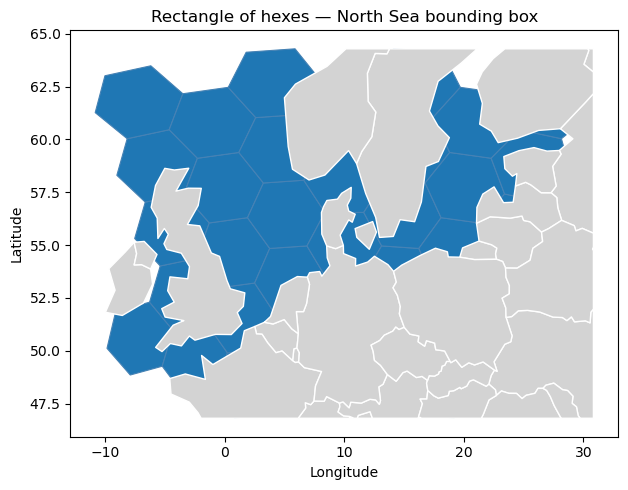

In [5]:
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
ax = rect_gdf.plot(figsize=(8, 5), edgecolor="steelblue", linewidth=0.8)
world.clip(rect_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white")
ax.set_title("Rectangle of hexes — North Sea bounding box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

Printing the hex IDs (the index) confirms they are plain `int64` values:

In [6]:
print(rect_gdf.index.values)

[47 15 30 49 72 99 11  6 17 32 51  4  1  8 19 34  9  2  0  5 14 18  7  3
 12 25 50 31 16 10 23 71 48 29 21 38 96]


## 2. Region of hexes from a shapely polygon

`region_of_hexes(polygon)` accepts any shapely geometry in WGS84 and keeps only hexes whose centres fall inside it. Here we define a rough outline of the North Sea.

In [7]:
north_sea = Polygon([
    (-5,  57),   # NW corner (Scotland)
    ( 2,  51),   # SW corner (English Channel entrance)
    ( 9,  53),   # southern Bight
    (12,  56),   # Kattegat approach
    ( 8,  58),   # Norwegian coast south
    ( 5,  62),   # northern limit
    (-3,  60),   # NW Scotland
    (-5,  57),   # close polygon
])

In [8]:
region_ids = hp.region_of_hexes(north_sea)
print(f"{len(region_ids)} hexes inside North Sea polygon")

14 hexes inside North Sea polygon


In [9]:
region_gdf = hp.to_geodataframe(region_ids)
region_gdf.head()

,geometry
49,"POLYGON ((-1.28734 56.04629, -2.37928 54.36421..."
72,"POLYGON ((-2.28151 59.10735, -3.40304 57.41622..."
6,"POLYGON ((4.20399 51.73985, 3.00359 50.10807, ..."
17,"POLYGON ((3.76491 54.84012, 2.50196 53.2046, -..."
32,"POLYGON ((3.23804 57.93637, 1.90488 56.29498, ..."


We add a colour column — the hex ID itself — to produce a simple choropleth that distinguishes each cell.

In [10]:
region_gdf["hex_id"] = region_gdf.index.astype(float)
region_gdf.head()

,geometry,hex_id
49,"POLYGON ((-1.28734 56.04629, -2.37928 54.36421...",49.0
72,"POLYGON ((-2.28151 59.10735, -3.40304 57.41622...",72.0
6,"POLYGON ((4.20399 51.73985, 3.00359 50.10807, ...",6.0
17,"POLYGON ((3.76491 54.84012, 2.50196 53.2046, -...",17.0
32,"POLYGON ((3.23804 57.93637, 1.90488 56.29498, ...",32.0


In [11]:
outline_gdf = gpd.GeoDataFrame(geometry=[north_sea], crs="EPSG:4326")

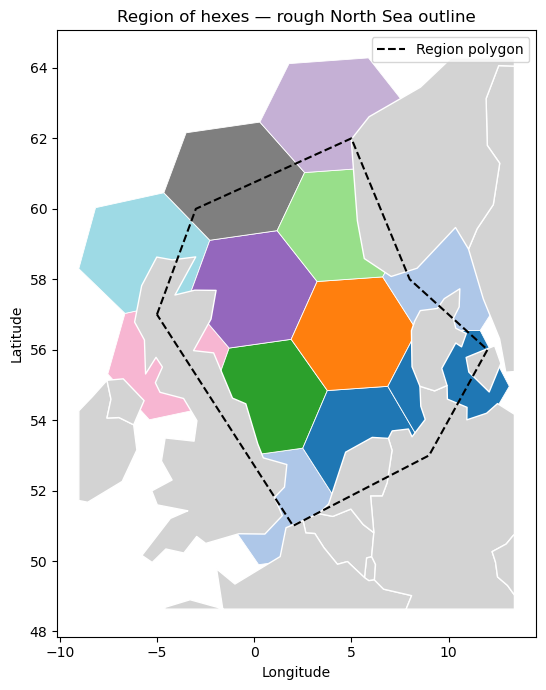

In [12]:
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
ax = region_gdf.plot(figsize=(7, 7), column="hex_id", cmap="tab20", edgecolor="white", linewidth=0.6, legend=False)
world.clip(region_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white")
outline_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5, linestyle="--", label="Region polygon")
ax.set_title("Region of hexes — rough North Sea outline")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()